In [3]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Embedding, LSTM, GlobalMaxPooling1D, SpatialDropout1D

We`ll perform sentiment analysis on a corpus of movie reviews. We’re asked to label each phrase on a scale of zero to four. The sentiment corresponding to each of the labels are:


0: negative

1: somewhat negative

2: neutral

3: somewhat positive

4: positive


In [4]:
df_train = pd.read_csv('/content/train.tsv', sep='\t')
print('train set: {0}'.format(df_train.shape))
df_train.head(10)

train set: (156060, 4)


,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,A series of escapades demonstrating the adage ...,1
1,2,1,A series of escapades demonstrating the adage ...,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2
5,6,1,of escapades demonstrating the adage that what...,2
6,7,1,of,2
7,8,1,escapades demonstrating the adage that what is...,2
8,9,1,escapades,2
9,10,1,demonstrating the adage that what is good for ...,2


In [26]:
df_train['Sentiment'].value_counts()

,count
Sentiment,
2,79582
3,32927
1,27273
4,9206
0,7072


In [5]:
df_test = pd.read_csv('/content/test.tsv', sep='\t')
print('test set: {0}'.format(df_test.shape))
df_test.head(10)

test set: (66292, 3)


,PhraseId,SentenceId,Phrase
0,156061,8545,An intermittently pleasing but mostly routine ...
1,156062,8545,An intermittently pleasing but mostly routine ...
2,156063,8545,An
3,156064,8545,intermittently pleasing but mostly routine effort
4,156065,8545,intermittently pleasing but mostly routine
5,156066,8545,intermittently pleasing but
6,156067,8545,intermittently pleasing
7,156068,8545,intermittently
8,156069,8545,pleasing
9,156070,8545,but


In [6]:
replace_list = {r"i'm": 'i am',
                r"'re": ' are',
                r"let’s": 'let us',
                r"'s":  ' is',
                r"'ve": ' have',
                r"can't": 'can not',
                r"cannot": 'can not',
                r"shan’t": 'shall not',
                r"n't": ' not',
                r"'d": ' would',
                r"'ll": ' will',
                r"'scuse": 'excuse',
                ',': ' ,',
                '.': ' .',
                '!': ' !',
                '?': ' ?',
                '\s+': ' '}
def clean_text(text):
    text = text.lower()
    for s in replace_list:
        text = text.replace(s, replace_list[s])
    text = ' '.join(text.split())
    return text

<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_982/3622506756.py:17: SyntaxWarning: invalid escape sequence '\s'
  '\s+': ' '}


In [23]:
X_train = df_train['Phrase'].apply(lambda p: clean_text(p))

In [24]:
print(X_train)

0         a series of escapades demonstrating the adage ...
1         a series of escapades demonstrating the adage ...
2                                                  a series
3                                                         a
4                                                    series
                                ...                        
156055                                            hearst is
156056                            forced avuncular chortles
156057                                   avuncular chortles
156058                                            avuncular
156059                                             chortles
Name: Phrase, Length: 156060, dtype: object


max phrase len: 53


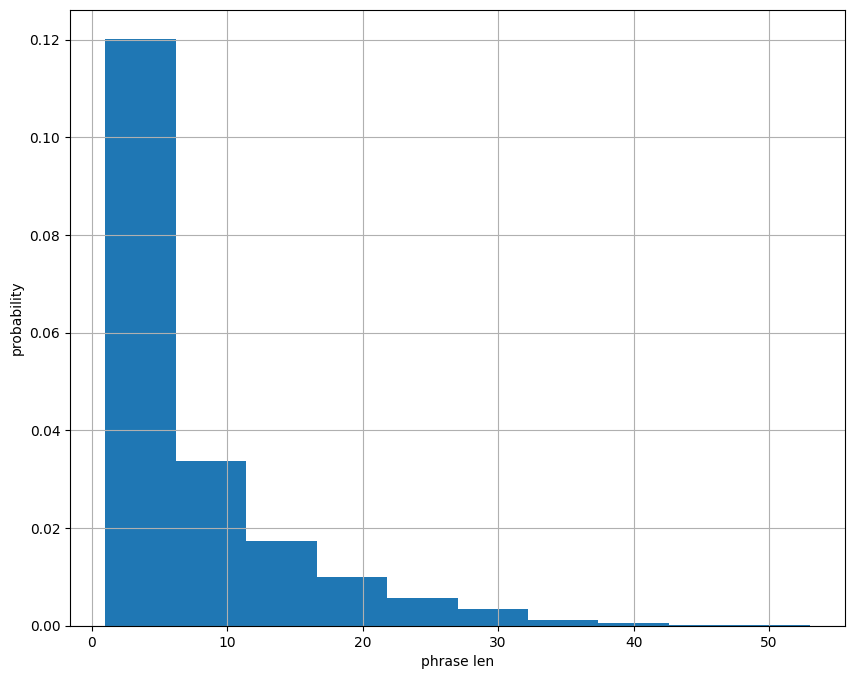

In [8]:
phrase_len = X_train.apply(lambda p: len(p.split(' ')))
max_phrase_len = phrase_len.max()
print('max phrase len: {0}'.format(max_phrase_len))
plt.figure(figsize = (10, 8))
plt.hist(phrase_len, density = True)
plt.xlabel('phrase len')
plt.ylabel('probability')
plt.grid()

In [9]:
y_train = df_train['Sentiment']

In [10]:
max_words = 8192
tokenizer = Tokenizer(
    num_words = max_words,
    filters = '"#$%&()*+-/:;<=>@[\]^_`{|}~'
)
tokenizer.fit_on_texts(X_train)
X_train = tokenizer.texts_to_sequences(X_train)
X_train = pad_sequences(X_train, maxlen = max_phrase_len)
y_train = to_categorical(y_train)

<>:4: SyntaxWarning: invalid escape sequence '\]'
<>:4: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipykernel_982/2235018941.py:4: SyntaxWarning: invalid escape sequence '\]'
  filters = '"#$%&()*+-/:;<=>@[\]^_`{|}~'


In [25]:
tokenizer.word_index

{'the': 1,
 ',': 2,
 'a': 3,
 'of': 4,
 'and': 5,
 'is': 6,
 '.': 7,
 'to': 8,
 'in': 9,
 'that': 10,
 'it': 11,
 'as': 12,
 'with': 13,
 'not': 14,
 'for': 15,
 'its': 16,
 'film': 17,
 'an': 18,
 'movie': 19,
 'this': 20,
 'but': 21,
 'be': 22,
 'on': 23,
 'you': 24,
 'by': 25,
 'more': 26,
 'are': 27,
 'his': 28,
 'one': 29,
 'have': 30,
 'about': 31,
 'at': 32,
 'or': 33,
 'than': 34,
 'from': 35,
 'all': 36,
 'like': 37,
 'has': 38,
 "'": 39,
 'so': 40,
 'out': 41,
 'story': 42,
 'rrb': 43,
 'up': 44,
 'who': 45,
 'good': 46,
 'too': 47,
 'most': 48,
 'into': 49,
 'lrb': 50,
 'will': 51,
 'if': 52,
 'what': 53,
 'time': 54,
 'their': 55,
 'no': 56,
 'characters': 57,
 'much': 58,
 "''": 59,
 'comedy': 60,
 'i': 61,
 'your': 62,
 'can': 63,
 'just': 64,
 'life': 65,
 'some': 66,
 'does': 67,
 'even': 68,
 'little': 69,
 'funny': 70,
 'well': 71,
 'way': 72,
 'very': 73,
 'been': 74,
 'any': 75,
 'would': 76,
 'make': 77,
 'only': 78,
 'which': 79,
 'he': 80,
 'movies': 81,
 'direct

In [11]:
batch_size = 512
epochs = 4

In [12]:
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim = max_words, output_dim = 256, input_length = max_phrase_len))
model_lstm.add(SpatialDropout1D(0.3))
model_lstm.add(LSTM(256, dropout = 0.3, recurrent_dropout = 0.3))
model_lstm.add(Dense(256, activation = 'relu'))
model_lstm.add(Dropout(0.3))
model_lstm.add(Dense(5, activation = 'softmax'))
model_lstm.compile(
    loss='categorical_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [13]:
history = model_lstm.fit(
    X_train,
    y_train,
    validation_split = 0.1,
    epochs = 8,
    batch_size = 2048
)

Epoch 1/8
69/69 ━━━━━━━━━━━━━━━━━━━━ 33s 264ms/step - accuracy: 0.5226 - loss: 1.2063 - val_accuracy: 0.5343 - val_loss: 1.1448
Epoch 2/8
69/69 ━━━━━━━━━━━━━━━━━━━━ 34s 275ms/step - accuracy: 0.6222 - loss: 0.9418 - val_accuracy: 0.5969 - val_loss: 1.0070
Epoch 3/8
69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 310ms/step - accuracy: 0.6631 - loss: 0.8390 - val_accuracy: 0.6021 - val_loss: 1.0006
Epoch 4/8
69/69 ━━━━━━━━━━━━━━━━━━━━ 40s 296ms/step - accuracy: 0.6754 - loss: 0.8054 - val_accuracy: 0.6064 - val_loss: 1.0069
Epoch 5/8
69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 276ms/step - accuracy: 0.6862 - loss: 0.7810 - val_accuracy: 0.6011 - val_loss: 1.0157
Epoch 6/8
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 289ms/step - accuracy: 0.6936 - loss: 0.7600 - val_accuracy: 0.5991 - val_loss: 1.0293
Epoch 7/8
69/69 ━━━━━━━━━━━━━━━━━━━━ 18s 266ms/step - accuracy: 0.6978 - loss: 0.7439 - val_accuracy: 0.6002 - val_loss: 1.0438
Epoch 8/8
69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 282ms/step - accuracy: 0.7040 - loss: 0.7275 - val_accuracy: 0.

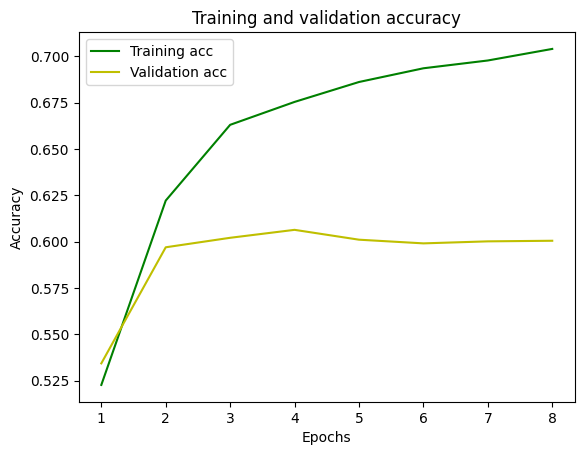

In [16]:
plt.clf()
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(1, len(acc) + 1)
plt.plot(epochs_range, acc, 'g', label='Training acc')
plt.plot(epochs_range, val_acc, 'y', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [19]:
x_test=df_test['Phrase'].apply(lambda p: clean_text(str(p)))
x_test=tokenizer.texts_to_sequences(x_test)
x_test=pad_sequences(x_test,maxlen=max_phrase_len)
pred=model_lstm.predict(x_test)
index=np.argmax(pred,axis=1)
df_test['Sentiment']=index
df_test.to_csv('submission.csv',index=False)
df_test.head()
#

2072/2072 ━━━━━━━━━━━━━━━━━━━━ 88s 42ms/step


,PhraseId,SentenceId,Phrase,Sentiment
0,156061,8545,An intermittently pleasing but mostly routine ...,2
1,156062,8545,An intermittently pleasing but mostly routine ...,2
2,156063,8545,An,2
3,156064,8545,intermittently pleasing but mostly routine effort,2
4,156065,8545,intermittently pleasing but mostly routine,2
